In [1]:
# 📌 Objectif : Entraîner un modèle GCN sur le graphe des superpixels

In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle



Epoch 0 | Loss: 0.6726 | Val Loss: 0.6735 | Train Acc: 0.7524 | Val Acc: 0.7519
Epoch 10 | Loss: 0.4056 | Val Loss: 0.4099 | Train Acc: 0.8825 | Val Acc: 0.8778
Epoch 20 | Loss: 0.3010 | Val Loss: 0.3016 | Train Acc: 0.8857 | Val Acc: 0.8852
Epoch 30 | Loss: 0.2666 | Val Loss: 0.2641 | Train Acc: 0.8873 | Val Acc: 0.8815
Epoch 40 | Loss: 0.2551 | Val Loss: 0.2510 | Train Acc: 0.8857 | Val Acc: 0.8852
Epoch 50 | Loss: 0.2476 | Val Loss: 0.2434 | Train Acc: 0.8857 | Val Acc: 0.8926
Epoch 60 | Loss: 0.2411 | Val Loss: 0.2383 | Train Acc: 0.8905 | Val Acc: 0.8926
Epoch 70 | Loss: 0.2354 | Val Loss: 0.2334 | Train Acc: 0.8952 | Val Acc: 0.8926
Epoch 80 | Loss: 0.2297 | Val Loss: 0.2281 | Train Acc: 0.8968 | Val Acc: 0.8963
Epoch 90 | Loss: 0.2237 | Val Loss: 0.2226 | Train Acc: 0.8968 | Val Acc: 0.8963
Epoch 100 | Loss: 0.2177 | Val Loss: 0.2168 | Train Acc: 0.8968 | Val Acc: 0.9000
Epoch 110 | Loss: 0.2122 | Val Loss: 0.2118 | Train Acc: 0.9111 | Val Acc: 0.9148
Epoch 120 | Loss: 0.2076 | 

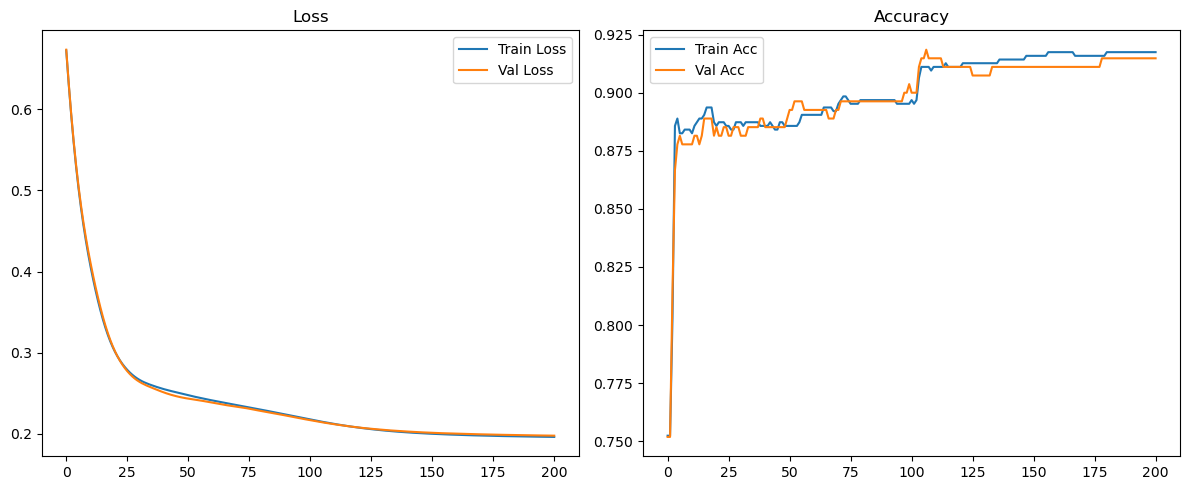


✅ Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.90      0.94       203
           1       0.76      0.96      0.85        67

    accuracy                           0.91       270
   macro avg       0.87      0.93      0.89       270
weighted avg       0.93      0.91      0.92       270


✅ Confusion Matrix:



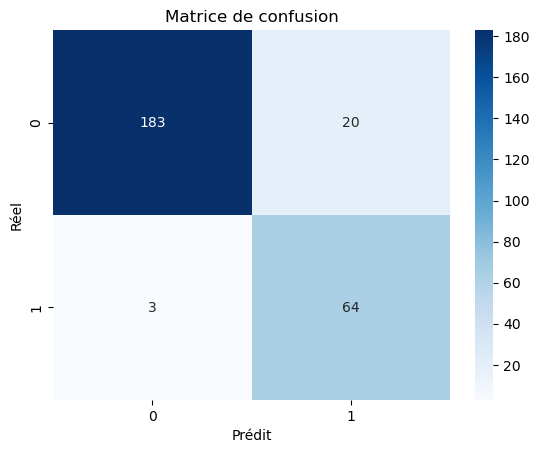

In [18]:

# === 1. Charger les données ===
data = torch.load("graph_superpixels.pt", weights_only=False)

# === 2. Split train/test ===
idx = torch.arange(data.num_nodes)
train_idx, test_idx = train_test_split(idx, test_size=0.3, stratify=data.y, random_state=42)

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

# === 3. Définir le modèle GCN ===
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

model = GCN(in_channels=data.num_node_features, hidden_channels=16, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# === 4. Entraînement avec historique ===
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

model.train()
for epoch in range(201):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    # Metrics
    model.eval()
    with torch.no_grad():
        pred = out.argmax(dim=1)
        train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
        val_loss = F.cross_entropy(out[data.test_mask], data.y[data.test_mask]).item()
        val_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()

    history["loss"].append(loss.item())
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    model.train()

# === 5. Sauvegarder le modèle et l'historique ===
torch.save(model.state_dict(), "gcn_model_superpixels.pt")
with open("gcn_history_superpixels.pkl", "wb") as f:
    pickle.dump(history, f)
print("✅ Modèle sauvegardé sous 'gcn_model_superpixels.pt'")
print("✅ Historique sauvegardé sous 'gcn_history_superpixels.pkl'")

# === 6. Afficher l'historique ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["accuracy"], label="Train Acc")
plt.plot(history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.tight_layout()
plt.show()

# === 7. Évaluation finale ===
model.eval()
preds = model(data.x, data.edge_index).argmax(dim=1)
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = preds[data.test_mask].cpu().numpy()

print("\n✅ Classification Report:\n")
print(classification_report(y_true, y_pred))

print("\n✅ Confusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()
